# Employee Attrition Prediction

## Objective

The purpose of this notebook is to build a machine learning model to predict employee attrition based on employee demographics, salary, job role, and workplace factors.

## Import Required Libraries

Import libraries for data analysis (`pandas`, `numpy`), visualization (`matplotlib`, `seaborn`), data preprocessing (`LabelEncoder`), dataset splitting (`train_test_split`), machine learning model building (`LogisticRegression`), and model evaluation (`accuracy_score`, `classification_report`, `confusion_matrix`).

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Load Dataset

Use `pd.read_csv()` to read the HR attrition dataset into a pandas DataFrame for machine learning analysis.

In [4]:
df = pd.read_csv('../data/Raw/WA_Fn-UseC_-HR-Employee-Attrition.csv')

## Preview Dataset

Use `df.head()` to display the first few rows of the dataset.

In [5]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Encode Categorical Columns

Use `LabelEncoder()` to convert categorical text columns into numerical values for machine learning algorithms.

In [6]:
label_encoder = LabelEncoder()

for column in df.select_dtypes(include='object').columns:
    df[column] = label_encoder.fit_transform(df[column])

## Define Features and Target Variable

Separate independent variables (X) and target variable (y) for model training and prediction.

In [7]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

## Split Dataset

Use `train_test_split()` to divide the dataset into training and testing sets for model evaluation.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Train Logistic Regression Model

Use Logistic Regression to train a machine learning model for employee attrition prediction.

In [9]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

c:\Users\Deepak khadka\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## Make Predictions

Use the trained model to predict employee attrition on the test dataset.

In [10]:
y_pred = model.predict(X_test)

## Model Accuracy

Use `accuracy_score()` to evaluate the prediction accuracy of the machine learning model.


In [11]:
accuracy = accuracy_score(y_test, y_pred)

print('Model Accuracy:', accuracy)

Model Accuracy: 0.8673469387755102


## Classification Report

Use `classification_report()` to evaluate model performance using precision, recall, and F1-score.

In [12]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.97      0.93       255
           1       0.50      0.18      0.26        39

    accuracy                           0.87       294
   macro avg       0.69      0.58      0.60       294
weighted avg       0.83      0.87      0.84       294



## Confusion Matrix

Use `confusion_matrix()` to compare actual and predicted employee attrition values.

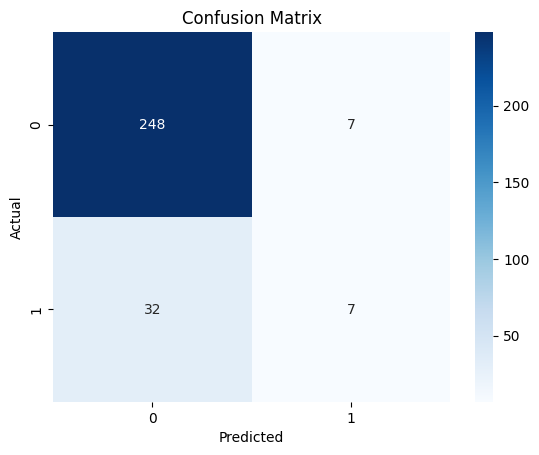

In [13]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Feature Importance Analysis

Analyze the impact of different employee features on attrition prediction using model coefficients.

In [14]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

feature_importance.sort_values(by='Coefficient', ascending=False).head(10)

,Feature,Coefficient
21,OverTime,0.332826
16,MaritalStatus,0.278902
32,YearsSinceLastPromotion,0.233381
19,NumCompaniesWorked,0.203318
30,YearsAtCompany,0.142011
14,JobRole,0.090087
3,Department,0.061881
6,EducationField,0.057638
10,Gender,0.045580
4,DistanceFromHome,0.029373


## Conclusion

The machine learning model successfully predicted employee attrition using employee demographics, workplace factors, and salary-related information. The analysis identified important factors influencing attrition and demonstrated the use of predictive analytics in HR decision-making.